№3 (2 балла)
Обучите модель линейной регрессии на данных согласно вашему варианту. Выведите
угловой коэффициент, точку пересечения с осью ординат и точность.

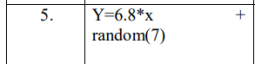

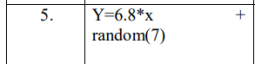

In [72]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score


X = np.array([258.0, 270.0, 294.0, 320.0, 342.0, 368.0, 396.0, 446.0, 480.0, 586.0])[:, np.newaxis]

def f(x):
    return 6.8 * x + np.random.random() * 7


y = np.array([f(x) for x in X])


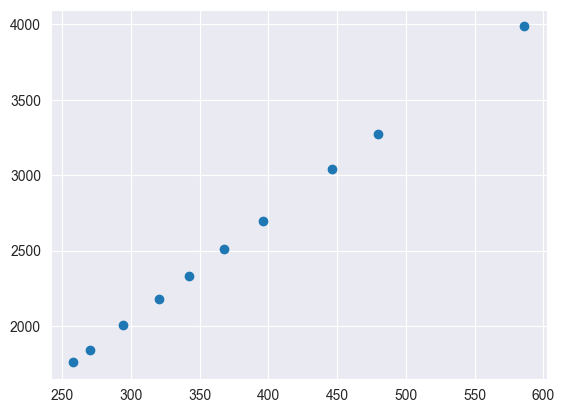

In [73]:
plt.scatter(X, y)

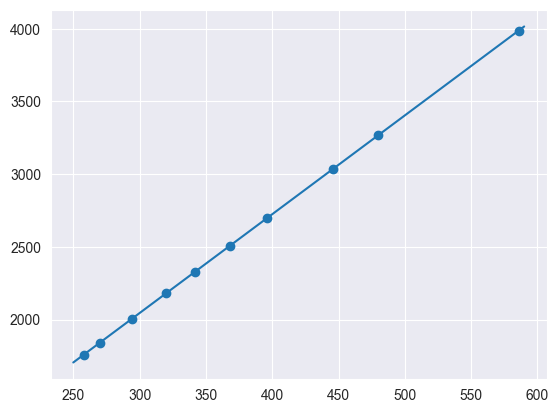

In [74]:
lr = LinearRegression()
lr.fit(X, y)
X_ = np.arange(250, 600, 10)[:, np.newaxis]
y_lr = lr.predict(X_)
plt.scatter(X, y)
plt.plot(X_, y_lr)

Выведите
угловой коэффициент, точку пересечения с осью ординат и точность.

In [75]:
slope = lr.coef_[0]
print(slope)

[6.79645935]


In [76]:
intercept = lr.intercept_
print(intercept)

[5.82025044]


In [77]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred_lr = lr.predict(X)
mse_lr = mean_squared_error(y, y_pred_lr)
r2_lr = r2_score(y, y_pred_lr)

print(f'R-квадрат: {r2_lr}')
print(f'MSE: {mse_lr}')


R-квадрат: 0.9999949955996279
MSE: 2.2297127431532324


№4 (3 балла)
Скачайте датасет https://cloud.mail.ru/public/SAi2/M1AzFm7BC, в котором по дням
записаны календарная информация и погодные условия, характеризующие
автоматизированные пункты проката велосипедов, а также число прокатов в этот день (это
значение необходимо предсказывать).
Для каждого дня проката известны следующие признаки (как они были указаны в источнике
данных):

 season: 1 - весна, 2 - лето, 3 - осень, 4 - зима
 yr: 0 - 2011, 1 - 2012
 mnth: от 1 до 12
 holiday: 0 - нет праздника, 1 - есть праздник
 weekday: от 0 до 6
 workingday: 0 - нерабочий день, 1 - рабочий день
 weathersit: оценка благоприятности погоды от 1 (чистый, ясный день) до 4 (ливень,
туман)
 temp: температура в Цельсиях
 atemp: температура по ощущениям в Цельсиях
 hum: влажность
 windspeed(mph): скорость ветра в милях в час
 windspeed(ms): скорость ветра в метрах в секунду
 cnt: количество арендованных велосипедов (это целевой признак, его мы будем
предсказывать)

Выполните следующие шаги:
1. Покажите на графиках, как целевой признак зависит от остальных. Каков характер
зависимости числа прокатов от месяца? Укажите один или два признака, от которых
число прокатов скорее всего зависит линейно.


In [78]:
import pandas as pd
df = pd.read_csv('bikes_rent.csv', delimiter=',')
df.head()

,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed(mph),windspeed(ms),cnt,Unnamed: 13
0,1,0,1,0,6,0,2,"14,110847","18,18125","80,5833","10,749882","4,80549038891",985,NaN
1,1,0,1,0,0,0,2,"14,902598","17,68695","69,6087","16,652113","7,44394859186",801,NaN
2,1,0,1,0,1,1,1,"8,050924","9,47025","43,7273","16,636703","7,43705990165",1349,NaN
3,1,0,1,0,2,1,1,"8,2","10,6061","59,0435","10,739832","4,80099776486",1562,NaN
4,1,0,1,0,3,1,1,"9,305237","11,4635","43,6957","12,5223","5,59780956638",1600,NaN


a) Числовые признаки (scatter plot)

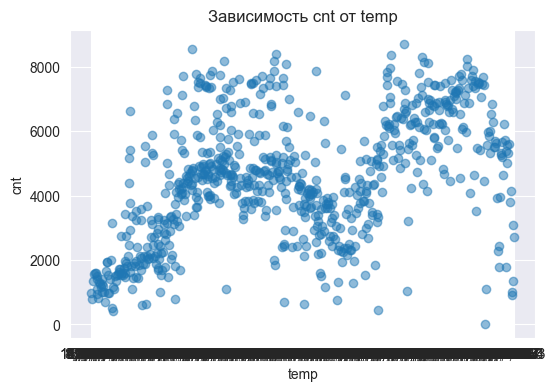

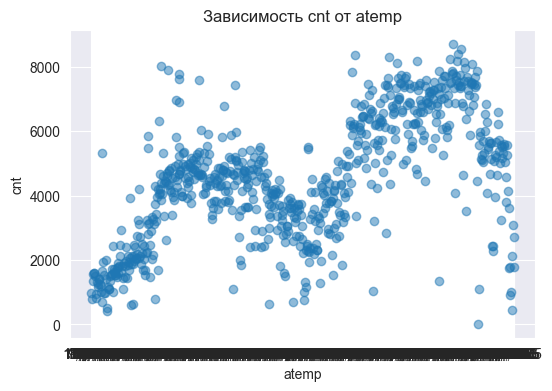

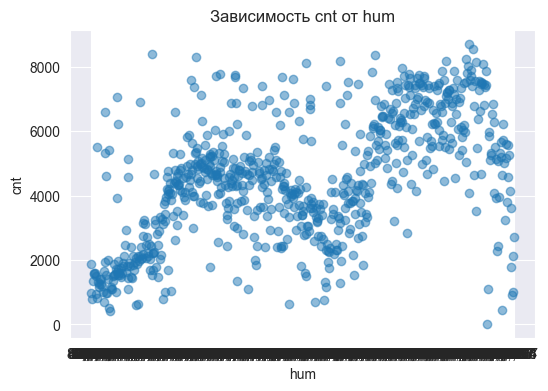

In [79]:
numeric_features = ['temp', 'atemp', 'hum']

for feature in numeric_features:
    plt.figure(figsize=(6,4))
    plt.scatter(df[feature], df['cnt'], alpha=0.5)
    plt.xlabel(feature)
    plt.ylabel('cnt')
    plt.title(f'Зависимость cnt от {feature}')
    plt.show()

<Figure size 600x400 with 0 Axes>

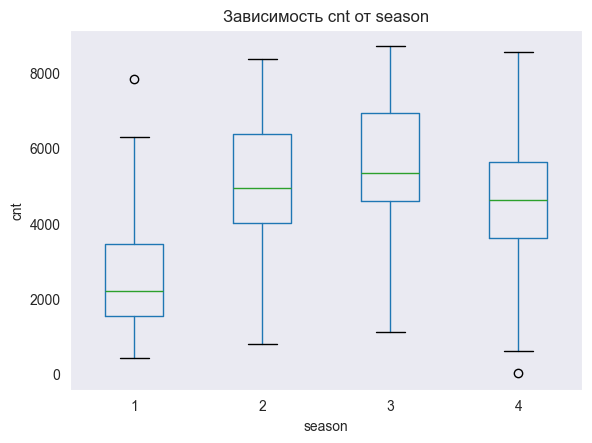

<Figure size 600x400 with 0 Axes>

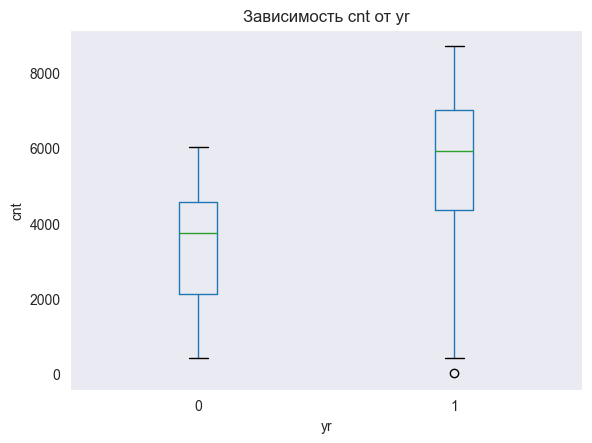

<Figure size 600x400 with 0 Axes>

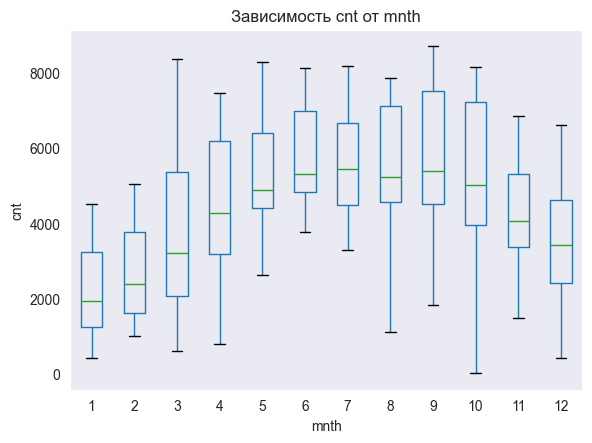

<Figure size 600x400 with 0 Axes>

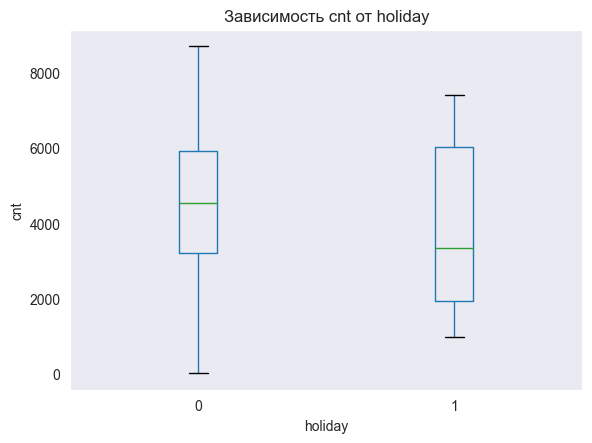

<Figure size 600x400 with 0 Axes>

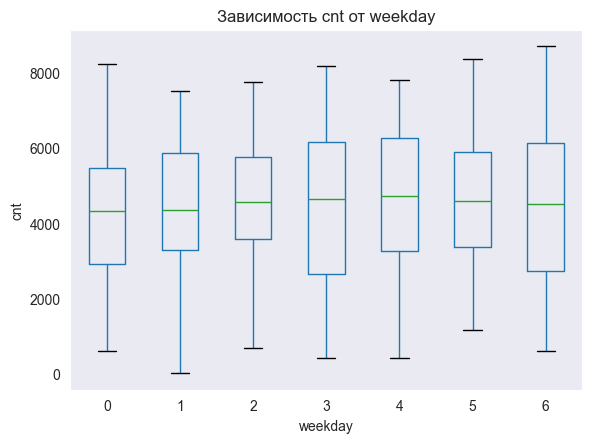

<Figure size 600x400 with 0 Axes>

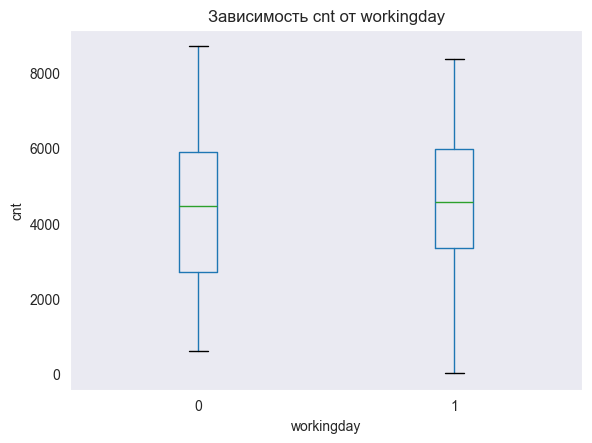

<Figure size 600x400 with 0 Axes>

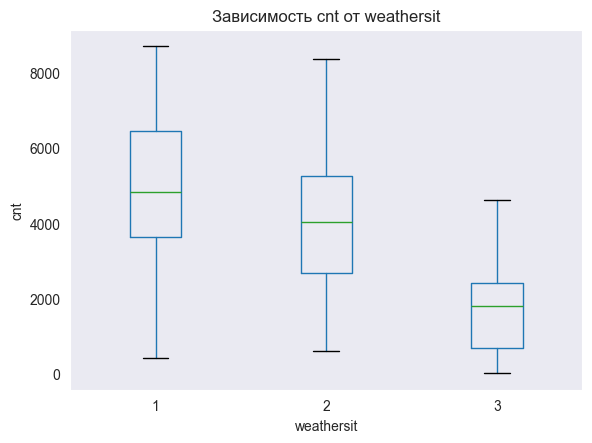

In [80]:
categorical_features = ['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit']

for feature in categorical_features:
    plt.figure(figsize=(6,4))
    df.boxplot(column='cnt', by=feature, grid=False)
    plt.xlabel(feature)
    plt.ylabel('cnt')
    plt.title(f'Зависимость cnt от {feature}')
    plt.suptitle('')
    plt.show()


temp (температура) — чем теплее, тем больше прокатов.

atemp (ощущаемая температура) — очень похожий линейный тренд.

2. Есть ли в данных похожие или дублирующие друг друга признаки? Как вы можете
показать их похожесть? Удалите такие признаки из датасета.

Дублирующие данные это
- windspeed(mph): скорость ветра в милях в час
- windspeed(ms): скорость ветра в метрах в секунду

In [81]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   season          731 non-null    int64  
 1   yr              731 non-null    int64  
 2   mnth            731 non-null    int64  
 3   holiday         731 non-null    int64  
 4   weekday         731 non-null    int64  
 5   workingday      731 non-null    int64  
 6   weathersit      731 non-null    int64  
 7   temp            731 non-null    object 
 8   atemp           731 non-null    object 
 9   hum             731 non-null    object 
 10  windspeed(mph)  731 non-null    object 
 11  windspeed(ms)   731 non-null    object 
 12  cnt             731 non-null    int64  
 13  Unnamed: 13     0 non-null      float64
dtypes: float64(1), int64(8), object(5)
memory usage: 80.1+ KB


                    temp     atemp       hum  windspeed(mph)  windspeed(ms)  \
temp            1.000000  0.991702  0.126963       -0.157944      -0.157944   
atemp           0.991702  1.000000  0.139988       -0.183643      -0.183643   
hum             0.126963  0.139988  1.000000       -0.248489      -0.248489   
windspeed(mph) -0.157944 -0.183643 -0.248489        1.000000       1.000000   
windspeed(ms)  -0.157944 -0.183643 -0.248489        1.000000       1.000000   
cnt             0.627494  0.631066 -0.100659       -0.234545      -0.234545   

                     cnt  
temp            0.627494  
atemp           0.631066  
hum            -0.100659  
windspeed(mph) -0.234545  
windspeed(ms)  -0.234545  
cnt             1.000000  


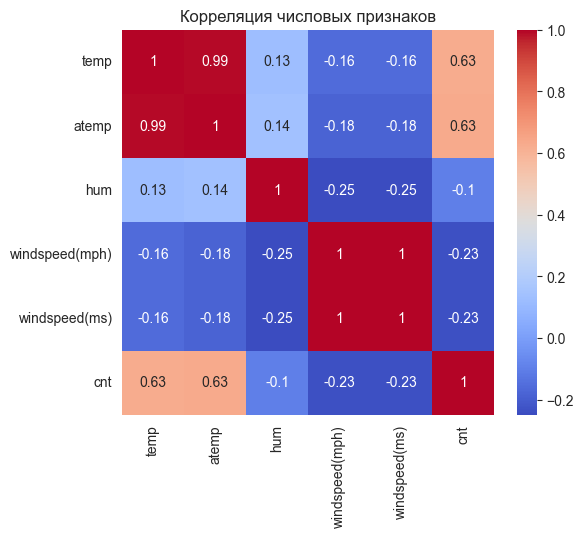

In [82]:
import seaborn as sns

numeric_features = ['temp', 'atemp', 'hum', 'windspeed(mph)', 'windspeed(ms)', 'cnt']
for col in numeric_features:
    df[col] = df[col].astype(str).str.replace(',', '.').astype(float)

corr_matrix = df[numeric_features].corr()
print(corr_matrix)

plt.figure(figsize=(6,5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Корреляция числовых признаков")
plt.show()


In [83]:
df = df.drop('windspeed(mph)', axis=1)
df = df.drop('atemp', axis=1)

3. Разбейте данные на тренировочные и тестовые. Обучите модель линейной
регрессии. Выведите точность предсказания модели для тестовых данных.

In [91]:
print(df.isna().sum())
df = df.dropna(axis=1)


season             0
yr                 0
mnth               0
holiday            0
weekday            0
workingday         0
weathersit         0
temp               0
hum                0
windspeed(ms)      0
cnt                0
Unnamed: 13      731
dtype: int64


In [92]:
df

,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,hum,windspeed(ms),cnt
0,1,0,1,0,6,0,2,14.110847,80.5833,4.805490,985.0
1,1,0,1,0,0,0,2,14.902598,69.6087,7.443949,801.0
2,1,0,1,0,1,1,1,8.050924,43.7273,7.437060,1349.0
3,1,0,1,0,2,1,1,8.200000,59.0435,4.800998,1562.0
4,1,0,1,0,3,1,1,9.305237,43.6957,5.597810,1600.0
...,...,...,...,...,...,...,...,...,...,...,...
726,1,1,12,0,4,1,2,10.420847,65.2917,10.486773,2114.0
727,1,1,12,0,5,1,2,10.386653,59.0000,4.656485,3095.0
728,1,1,12,0,6,0,2,10.386653,75.2917,3.725374,1341.0
729,1,1,12,0,0,0,1,10.489153,48.3333,10.505372,1796.0


In [97]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LassoCV

X = df.drop('cnt', axis=1)
y = df['cnt']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

lasso = LassoCV(cv=5)
lasso.fit(X_train, y_train)
lasso.score(X_test, y_test)
print(lasso.coef_ )

y_pred = lasso.predict(X_test)
print("R^2 на тестовой выборке:", r2_score(y_test, y_pred))

important_features = X.columns[lasso.coef_ != 0]
print(important_features)



[ 516.98992053 1949.52866577  -39.00623715 -101.66615134   67.36891484
  150.43428109 -575.04597408  129.14851019   -9.58428194  -79.81931369]
R^2 на тестовой выборке: 0.8207146657113973
Index(['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday',
       'weathersit', 'temp', 'hum', 'windspeed(ms)'],
      dtype='object')
